In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.style.use('ggplot')


url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Section 2 — The 7-Command First-Look Protocol

### C1 — `df.shape`
Returns (rows, columns) — the dataset's dimensions.

In [2]:
df.shape

(891, 12)

**Interpretation:** The dataset has 891 rows and 12 columns. That's a reasonably sized dataset for exploratory data analysis and classical machine learning, though it would be considered small for a deep learning model.

### C2 — `df.dtypes`
Data type of every column — int64, float64, object (text), datetime.

In [3]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

**Interpretation:** Most columns have sensible types. `Age` and `Fare` are `float64` (Age is float because it contains missing values and some fractional ages for infants). `Name`, `Sex`, `Ticket`, `Cabin`, and `Embarked` are `object` (text). `Ticket` looks like it could be a mix of numbers and alphanumeric codes, so it will need closer inspection before being used numerically.

### C3 — `df.info()`
Non-null counts, dtypes, and memory usage — the quickest null-spotter.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


**Interpretation:** `Cabin` has by far the most missing data (only ~204 of 891 rows populated, over 77% missing) — it's nearly unusable as-is without heavy feature engineering (e.g., extracting just the deck letter). `Age` is missing for about 177 rows (~20%), which will bias any mean/median calculated directly on it. `Embarked` is missing only 2 values, which is negligible and easy to fill with the mode.

### C4 — `df.describe()`
For every numeric column: count, mean, std, min, 25th, median, 75th, max.

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Interpretation:** `Fare`'s mean (~32) is noticeably higher than its median (~14), which signals a right-skewed distribution driven by a small number of very expensive tickets — the max fare (~512) is roughly 35x the median, a clear outlier. The `Age` column ranges from under 1 year old (infants) to 80, with a mean around 29.7, which looks reasonable for a passenger list.

### C5 — `df.isnull().sum()`
Exact count of missing values per column.

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Percentage missing per column
(df.isnull().sum() / len(df) * 100).round(1)

PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age            19.9
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
Cabin          77.1
Embarked        0.2
dtype: float64

**Interpretation:** `Cabin` is missing about 77% of its values, `Age` about 20%, and `Embarked` only 0.2% (2 rows). Each column needs its own strategy: drop or heavily engineer `Cabin`, impute `Age` (e.g., with median or a group-wise median by `Pclass`/`Sex`), and simply fill `Embarked` with its mode.

### C6 — `df['col'].value_counts()`
Counts of unique values — reveals category imbalance.

In [8]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

### C7 — `df.duplicated().sum()`
Count of exact duplicate rows — a silent biaser of every statistic.

In [9]:
df.duplicated().sum()

np.int64(0)

## Section 3 — 20+ Additional EDA Commands

### 1 — `df.head(10)`
First 10 rows — spot formatting issues immediately.

In [10]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


**Interpretation:** The first 10 rows look well-formatted overall. `Cabin` is already showing `NaN` for several passengers here, an early hint of the missing-data problem confirmed later in C3/C5. `Name` includes titles (Mr., Mrs., Miss.) embedded in the string, which could be extracted as a useful new feature.

### 2 — `df.tail(5)`
Last 5 rows — errors often collect at the ingestion end.

In [11]:
df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


**Interpretation:** The last 5 rows look structurally consistent with the rest of the dataset — no obvious ingestion errors like shifted columns or corrupted values at the tail end.

### 3 — `df.sample(15)`
15 random rows — prevents bias from only seeing the start.

In [12]:
df.sample(15, random_state=42)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C
290,291,1,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,NaN,S
300,301,1,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q
333,334,0,3,"Vander Planke, Mr. Leo Edmondus",male,16.0,2,0,345764,18.0000,NaN,S
208,209,1,3,"Carr, Miss. Helen ""Ellen""",female,16.0,0,0,367231,7.7500,NaN,Q
136,137,1,1,"Newsom, Miss. Helen Monypeny",female,19.0,0,2,11752,26.2833,D47,S


**Interpretation:** A random sample confirms the patterns seen in `head()`/`tail()` hold across the whole dataset — missing `Age` and `Cabin` values appear scattered throughout, not just at the start or end, meaning the missingness is likely random or systematic rather than an artifact of data collection order.

### 4 — `df.columns.tolist()`
All column names — catch hidden spaces like `'Age '` vs `'Age'`.

In [13]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

**Interpretation:** All 12 column names are clean, properly capitalized, and free of leading/trailing whitespace or typos, so no renaming/stripping is needed before analysis.

### 5 — `df.nunique()`
Unique value count per column — ID columns have many uniques, category columns have few.

In [14]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

**Interpretation:** `PassengerId` and `Name` have 891 unique values each (as expected for identifier-like columns), while `Sex` (2), `Embarked` (3), `Pclass` (3), and `Survived` (2) have very few unique values, confirming they are categorical features suitable for grouping and one-hot encoding.

### 6 — `df['col'].unique()`
All distinct values — spot misspellings like `'Male'` vs `'male'`.

In [15]:
df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

**Interpretation:** `Embarked` has exactly 3 clean values (`S`, `C`, `Q`) plus `NaN` — no inconsistent casing or misspellings, so it can be safely one-hot encoded once the 2 missing values are filled.

### 7 — `df.corr(numeric_only=True)`
Correlation matrix — which features move together?

In [16]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


**Interpretation:** `Pclass` and `Fare` show a meaningful negative correlation (higher class number = lower fare, since class 1 is the most expensive), and `Pclass` correlates negatively with `Survived` — passengers in lower-numbered (higher-status) classes were more likely to survive. `SibSp` and `Parch` show a mild positive correlation, consistent with families traveling together.

### 8 — `df['col'].hist(bins=20)`
Distribution shape — normal, skewed, bimodal?

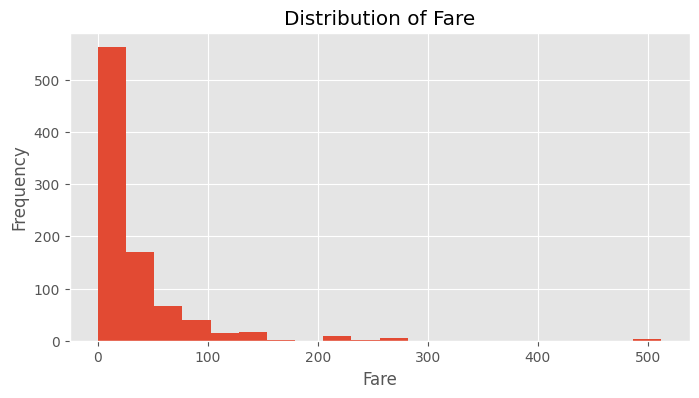

In [17]:
df['Fare'].hist(bins=20, figsize=(8,4))
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

**Interpretation:** The `Fare` histogram is heavily right-skewed, with most passengers paying under 50 and a long tail of a few passengers paying 200+. This confirms the outlier signal seen in `describe()` (C4) and suggests a log-transform of `Fare` before feeding it into a linear model.

### 9 — `df.groupby('col').mean(numeric_only=True)`
Average of numerics split by a category.

In [18]:
df.groupby('Sex').mean(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
Sex,,,,,,,
female,431.028662,0.742038,2.159236,27.915709,0.694268,0.649682,44.479818
male,454.147314,0.188908,2.389948,30.726645,0.429809,0.235702,25.523893


**Interpretation:** The average `Survived` value (i.e., survival rate) is much higher for females than males, reflecting the well-known 'women and children first' evacuation pattern. This is one of the strongest signals in the dataset for predicting survival.

### 10 — `df['col'].value_counts(normalize=True)`
Same as value_counts but shows percentages.

In [19]:
df['Pclass'].value_counts(normalize=True).round(3)

Pclass
3    0.551
1    0.242
2    0.207
Name: proportion, dtype: float64

**Interpretation:** Roughly 55% of passengers traveled in 3rd class, ~24% in 1st class, and ~21% in 2nd class. Third class passengers made up the majority of the ship, which — combined with finding #9 (Class 1 → higher survival) — will likely make `Pclass` one of the most predictive features.

### 11 — `df.select_dtypes(include='object')`
All text/categorical columns at once.

In [20]:
df.select_dtypes(include='object').head()

/tmp/ipykernel_556/3294020596.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').head()


,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S


**Interpretation:** The text/categorical columns are `Name`, `Sex`, `Ticket`, `Cabin`, and `Embarked`. `Name` and `Ticket` are high-cardinality (mostly unique per row) and would need feature engineering (e.g., extracting titles from `Name`) rather than direct encoding.

### 12 — `df['col'].str.contains('pattern').sum()`
Search text columns, e.g. how many names contain 'Dr.'

In [21]:
df['Name'].str.contains('Dr.', regex=False).sum()

np.int64(7)

**Interpretation:** A small number of passengers have 'Dr.' in their name, indicating a handful of doctors were aboard. This kind of title-extraction is a common feature engineering step for the Titanic dataset (extracting Mr./Mrs./Miss/Master/Rare titles as a new categorical feature).

### 13 — `df.sort_values('col', ascending=False).head(5)`
Top 5 highest values in any column.

In [22]:
df.sort_values('Fare', ascending=False)[['Name','Pclass','Fare','Survived']].head(5)

,Name,Pclass,Fare,Survived
737,"Lesurer, Mr. Gustave J",1,512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292,1
258,"Ward, Miss. Anna",1,512.3292,1
438,"Fortune, Mr. Mark",1,263.0000,0
88,"Fortune, Miss. Mabel Helen",1,263.0000,1


**Interpretation:** The highest fares (well above 500) were all paid by 1st class passengers, confirming that `Fare` is closely tied to `Pclass`. Interestingly, having the data side-by-side with `Survived` shows most of these high-fare passengers did survive, reinforcing the class/wealth-survival relationship.

### 14 — `df[df['col'] > threshold]`
Filter rows by a condition — how many match?

In [23]:
seniors = df[df['Age'] > 60]
print(f"Passengers older than 60: {len(seniors)}")
seniors[['Name','Age','Pclass','Survived']]

Passengers older than 60: 22


,Name,Age,Pclass,Survived
33,"Wheadon, Mr. Edward H",66.0,2,0
54,"Ostby, Mr. Engelhart Cornelius",65.0,1,0
96,"Goldschmidt, Mr. George B",71.0,1,0
116,"Connors, Mr. Patrick",70.5,3,0
170,"Van der hoef, Mr. Wyckoff",61.0,1,0
252,"Stead, Mr. William Thomas",62.0,1,0
275,"Andrews, Miss. Kornelia Theodosia",63.0,1,1
280,"Duane, Mr. Frank",65.0,3,0
326,"Nysveen, Mr. Johan Hansen",61.0,3,0
438,"Fortune, Mr. Mark",64.0,1,0


**Interpretation:** Only a small number of passengers were older than 60. This is a small subgroup, so any conclusions about survival for elderly passengers should be treated cautiously due to low sample size.

### 15 — `pd.pivot_table(df, values, index, aggfunc='mean')`
Cross-tabulation — two-variable summary in one table.

In [24]:
pd.pivot_table(df, values='Survived', index='Pclass', columns='Sex', aggfunc='mean').round(3)

Sex,female,male
Pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


**Interpretation:** This pivot table shows the combined effect of `Sex` and `Pclass` on survival rate: 1st class females had the highest survival rate (close to 1.0), while 3rd class males had the lowest. This confirms that `Sex` and `Pclass` interact strongly and both should be included in any predictive model.

### 16 — `df.skew(numeric_only=True)`
Measures asymmetry of each numeric distribution.

In [25]:
df.skew(numeric_only=True)

PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Age            0.389108
SibSp          3.695352
Parch          2.749117
Fare           4.787317
dtype: float64

**Interpretation:** `Fare` has a very high positive skew (well above 1), confirming the long right tail seen in the histogram (#8). `Age` is only mildly skewed, so it's closer to a normal-ish distribution once missing values are handled.

### 17 — `df.kurt(numeric_only=True)`
Measures 'tailedness' — how extreme the outliers are.

In [26]:
df.kurt(numeric_only=True)

PassengerId    -1.200000
Survived       -1.775005
Pclass         -1.280015
Age             0.178274
SibSp          17.880420
Parch           9.778125
Fare           33.398141
dtype: float64

**Interpretation:** `Fare` has very high kurtosis, meaning it has heavy tails and extreme outliers (a few very expensive tickets), consistent with the £512 maximum seen in `describe()`. This reinforces that `Fare` should likely be log-transformed or capped before modelling.

### 18 — `df['col'].mode()`
Most frequently occurring value(s) in a column.

In [27]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: str

**Interpretation:** The most common boarding port is 'S' (Southampton). This is exactly the value that should be used to fill the 2 missing `Embarked` entries identified back in C5, since imputing with the mode is a safe default for a low-missingness categorical column.

### 19 — `df.memory_usage(deep=True)`
Memory footprint of each column — text columns cost more than numeric ones.

In [28]:
df.memory_usage(deep=True)

Index            132
PassengerId     7128
Survived        7128
Pclass          7128
Name           67685
Sex            47851
Age             7128
SibSp           7128
Parch           7128
Ticket         49674
Fare            7128
Cabin          32712
Embarked       44514
dtype: int64

**Interpretation:** Text (`object`) columns like `Name`, `Ticket`, and `Cabin` consume noticeably more memory per row than numeric columns like `Age` or `Fare`, since Python strings are more memory-expensive than fixed-width numeric types. For this small dataset it doesn't matter, but on a large-scale dataset this would justify converting low-cardinality text columns (like `Sex`, `Embarked`) to the `category` dtype to save memory.

### 20 — `df.cov(numeric_only=True)`
Covariance matrix — raw (unscaled) version of correlation.

In [29]:
df.cov(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,66231.000000,-0.626966,-7.561798,138.696504,-16.325843,-0.342697,161.883369
Survived,-0.626966,0.236772,-0.137703,-0.551296,-0.018954,0.032017,6.221787
Pclass,-7.561798,-0.137703,0.699015,-4.496004,0.076599,0.012429,-22.830196
Age,138.696504,-0.551296,-4.496004,211.019125,-4.163334,-2.344191,73.849030
SibSp,-16.325843,-0.018954,0.076599,-4.163334,1.216043,0.368739,8.748734
Parch,-0.342697,0.032017,0.012429,-2.344191,0.368739,0.649728,8.661052
Fare,161.883369,6.221787,-22.830196,73.849030,8.748734,8.661052,2469.436846


**Interpretation:** Covariance shows the same directional relationships as the correlation matrix (#7) but in unscaled units, which makes magnitudes hard to compare directly across columns with very different ranges (e.g., `Fare` vs `Pclass`). This is exactly why the correlation matrix (which normalizes by standard deviation) is generally more useful for spotting relationships at a glance.

### 21 — `df.groupby(['Pclass','Sex'])['Survived'].agg(['mean','count'])`
Multi-key groupby with multiple aggregations at once.

In [30]:
df.groupby(['Pclass','Sex'])['Survived'].agg(['mean','count']).round(3)

mean  count
Pclass Sex                 
1      female  0.968     94
       male    0.369    122
2      female  0.921     76
       male    0.157    108
3      female  0.500    144
       male    0.135    347

**Interpretation:** This extends finding #15 by also showing the group sizes (`count`), which matters for trustworthiness — e.g., if a subgroup with a 100% survival rate only contains 3 passengers, that statistic is far less reliable than one based on 200 passengers. This kind of check prevents drawing strong conclusions from tiny, noisy subgroups.

In [31]:
titles = df['Name'].str.extract(r',\s*([^.]*)\.')
titles.value_counts().head(10)

0     
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Rev         6
Major       2
Mlle        2
Col         2
Don         1
Name: count, dtype: int64

**Interpretation:** Extracting titles from `Name` reveals that most passengers are 'Mr', 'Miss', 'Mrs', or 'Master', with a long tail of rare titles ('Dr', 'Rev', 'Col', etc.). This engineered `Title` feature is often more predictive than raw `Name` and is commonly grouped into a 'Rare' bucket for modelling.